In [2]:
import reciprocalspaceship as rs
import numpy as np
import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.append(homepath)
idx = path_parts.index("Nextcloud2")
path = os.sep.join(path_parts[:idx + 1]) +"/phase_retrieval/algos/"
sys.path.append(path)
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from meteor import rsmap
from meteor.utils import cut_resolution
from systematic_plots import setup_logger, run_plots
logger = setup_logger()

In [6]:
dataloc = homepath + "../data/MAXIV_ECH_new/"
dataloc_dark = dataloc + "initial/ech-full_dark_dimple.mtz"
dataloc_light = dataloc + "initial/ech-light_dimple.mtz"

ds_dark = rs.read_mtz(dataloc_dark)
ds_light = rs.read_mtz(dataloc_light)
print(ds_dark.columns)
print(ds_light.columns)
dark_columns = {
    "amplitude_column": "F",
    "uncertainty_column": "SIGF",
    "phase_column": "PHIC",
}
light_columns = {
    "amplitude_column": "F",
    "uncertainty_column": "SIGF",
    "phase_column": "PHI_dark",
}
ds_light[light_columns["phase_column"]] = ds_dark[dark_columns["phase_column"]]
map_dark = rsmap.Map(ds_dark, **dark_columns)
map_light_unscaled = rsmap.Map(ds_light, **light_columns)
from meteor.scale import scale_maps
map_light = scale_maps(reference_map=map_dark, map_to_scale=map_light_unscaled)


Index(['FreeR_flag', 'F', 'SIGF', 'FC', 'PHIC', 'FC_ALL', 'PHIC_ALL', 'FWT',
       'PHWT', 'DELFWT', 'PHDELWT', 'FOM', 'FC_ALL_LS', 'PHIC_ALL_LS'],
      dtype='object')
Index(['FreeR_flag', 'F', 'SIGF', 'FC', 'PHIC', 'FC_ALL', 'PHIC_ALL', 'FWT',
       'PHWT', 'DELFWT', 'PHDELWT', 'FOM', 'FC_ALL_LS', 'PHIC_ALL_LS'],
      dtype='object')


In [7]:
from photolyase import loading_diffmaps
from meteorize import find_largest_blobs2
# import find_largest_blobs2 
map_sampling = 3
saveloc = "diffmaps_tmp.mtz"
diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    saveloc = saveloc,
    # map_sampling=map_sampling,
)


Reading from diffmaps_tmp.mtz


In [8]:

key = "tv"
comparison_key = "vanilla_diffmap"
scale_diffmap = True 


if scale_diffmap:
    diffmap = scale_maps(reference_map=diffmaps[comparison_key], map_to_scale=diffmaps[key])
else:
    diffmap = diffmaps[key]

# pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling,
#                                               threshold=0.5, minimum_size=3)

In [45]:
from plotting3d import slice_3d, panels_3d
map_list = [
    map_dark,
    map_light,
    diffmap
]
density_list = [mm.to_3d_numpy_map(map_sampling=map_sampling) for mm in map_list]
if False:
    %matplotlib widget
    _ = panels_3d(density_list)
        # "blob_selection_func": find_most_positive_blobs_fixed_basis,
from meteorize import find_most_positive_blobs_fixed_basis, find_most_positive_blobs_np
# pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling, threshold=0.3, blob_selection_func=find_most_positive_blobs_fixed_basis)
pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling, threshold=0.3, blob_selection_func=find_most_positive_blobs_np)
print(f"Found {np.max(pos_blobs2)} positive and {np.max(neg_blobs2)} negative blobs")


Found 33 positive and 47 negative blobs


In [46]:

neg_blobs_vis = neg_blobs2.copy()
neg_blobs_vis = neg_blobs_vis.astype(float)

neg_blobs_vis[neg_blobs_vis == 0] = np.nan
# _ = slice_3d(neg_blobs_vis, imkwargs=dict(vmax = 30))


In [ ]:

from output_eval import slice_3d
# _ = slice_3d(np.ones((30, 10, 10)), )#imkwargs=dict(vmax=vmax, vmin=-vmax, cmap="bwr",))
%matplotlib widget
_ = slice_3d(neg_blobs_vis, )

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=map_sampling)
vmax = max(np.max(diffmap_np), -np.min(diffmap_np))*0.4
_ = slice_3d(diffmap_np, vmax=vmax, vmin=-vmax, cmap="bwr",)


In [33]:
diffmap_np
# find the 99th percentile 
pos_threshold = np.percentile(diffmap_np, .1)/np.min(diffmap_np)
pos_threshold

0.12813706740399625

In [ ]:
plt.close("all")

%matplotlib inline
key = "tv"
comparison_key = "vanilla_diffmap"
scale_diffmap = True 


if scale_diffmap:
    diffmap = scale_maps(reference_map=diffmaps[comparison_key], map_to_scale=diffmaps[key])
else:
    diffmap = diffmaps[key]

# pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling,
#                                               threshold=0.5, minimum_size=3)


2025-08-08 10:23:44,557: systematic_plots: INFO: Function selection provided: ['many_negsum_best_guess', 'many_negsum_many_thresh', 'single_negsum_overview', 'show_comparison'] (systematic_plots.py:1493)
2025-08-08 10:23:44,557: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1242)
2025-08-08 10:23:44,746: systematic_plots: INFO: Number of Masks: 50 (systematic_plots.py:211)
2025-08-08 10:23:46,704: meteorize: INFO: Intersection Average: 4.63 ± 1.04 (meteorize.py:219)
2025-08-08 10:23:46,704: meteorize: INFO: Intersection Average Inverse: 0.23 ± 0.05 (meteorize.py:220)
2025-08-08 10:23:46,826: root: INFO: Total mask sum: 787, Total weight sum: 164.72209161520004 (meteorize.py:229)
2025-08-08 10:23:47,009: systematic_plots: INFO: Number of Masks: 47 (systematic_plots.py:211)
2025-08-08 10:23:48,898: meteorize: INFO: Intersection Average: 4.42 ± 1.05 (meteorize.py:219)
2025-08-08 10:23:48,898: meteorize: INFO: Intersection Average Inverse: 0.24 ± 0.05 (meteo

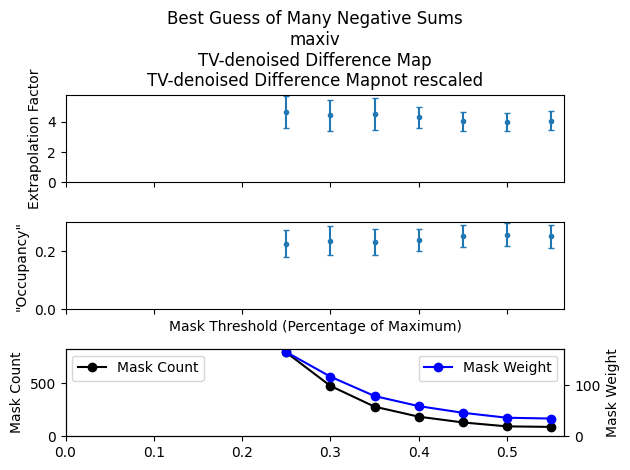

2025-08-08 10:23:55,965: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1261)
2025-08-08 10:23:56,152: systematic_plots: INFO: Calculating many negsum for threshold 0.25 (systematic_plots.py:257)
2025-08-08 10:23:58,238: systematic_plots: INFO: Calculating many negsum for threshold 0.45 (systematic_plots.py:257)
2025-08-08 10:23:59,499: root: INFO: Unique intersection points: [2.98066627 2.98069933 2.98070113 2.98143861 2.98148925 2.98150878
                               3.84643423 3.84644337 3.85392478 3.85395815 3.85702662 3.85702797
                               3.85704585 3.87141008 3.8737069  3.8738185  3.88256109 3.88259261
                               3.88921557 3.89451578 3.89453288 3.89453358 3.97623014 4.39659792
                               4.39661497 4.3966159  4.3978594  4.39786009 4.39786171 5.12196533
                               5.12196657 5.12197818 5.16942024 5.16944412 5.16945082 5.19155186
                               5.19155

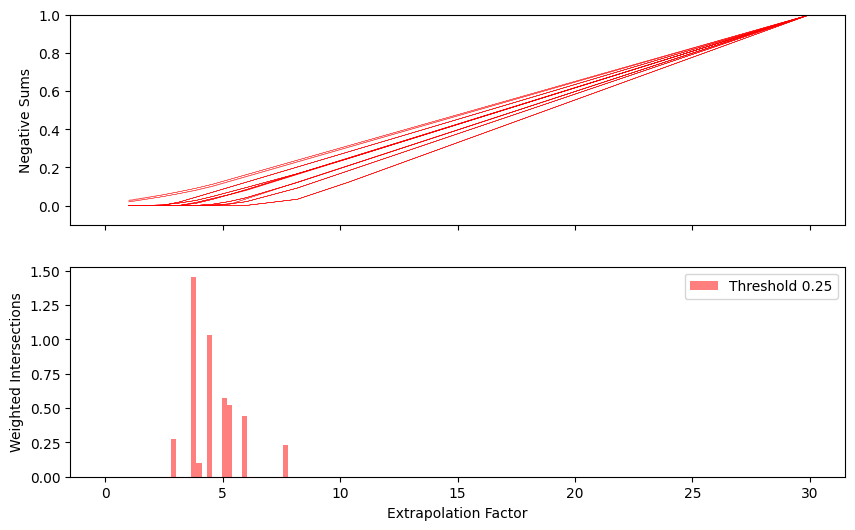

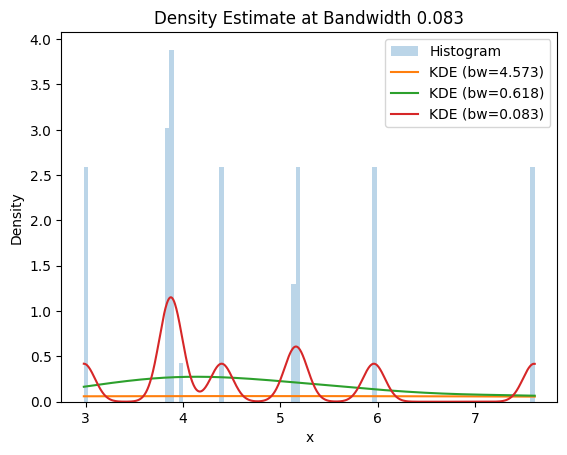

/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/systematic_plots.py:1704: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Plot 1: Mode Trace


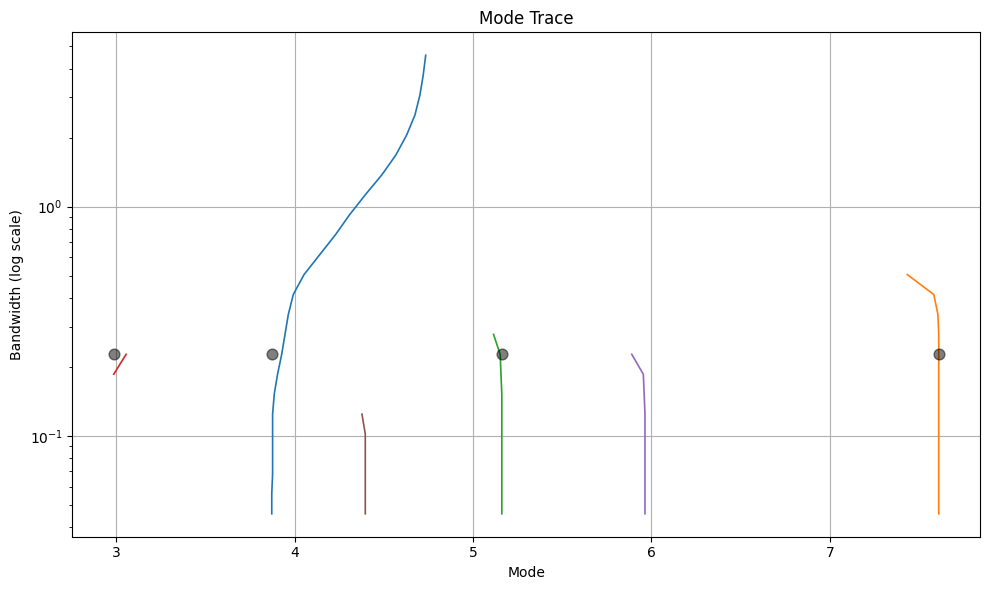

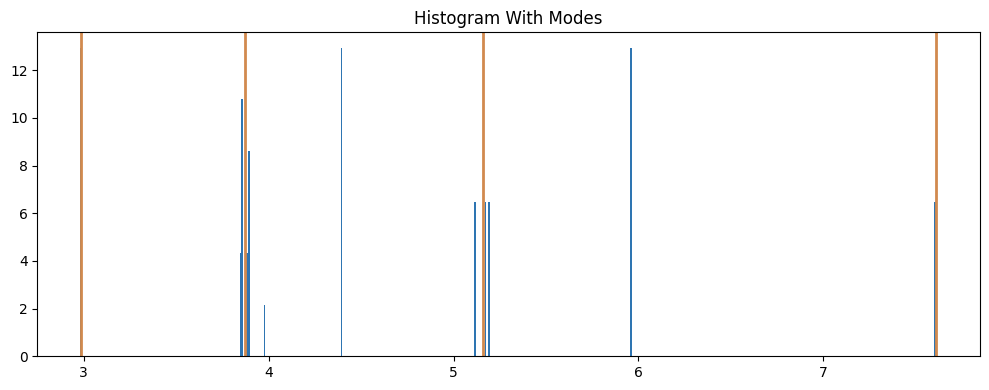

2025-08-08 10:24:00,047: root: INFO: Unique intersection points: [3.42700806 3.42703524 3.42704802 3.43179063 3.43181465 3.44218969
                               3.44219295 3.44220255 3.50347026 3.50347163 4.65844598 4.65846723
                               4.65846791 4.67544795 4.67544865 4.67544934] (<string>:28)


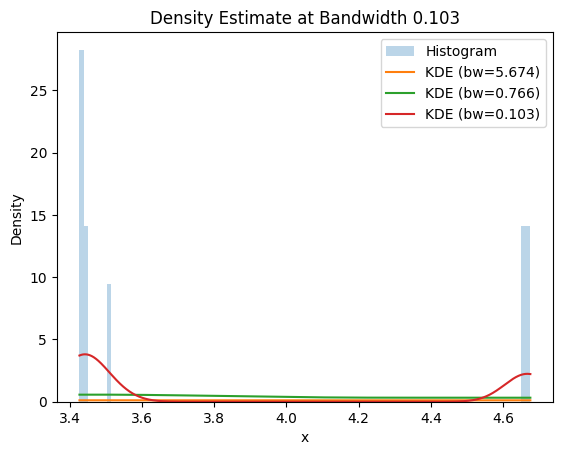

/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/systematic_plots.py:1704: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Plot 1: Mode Trace
2025-08-08 10:24:00,319: systematic_plots: WARNING: Error analyzing/plotting modes: 'Mode' (<string>:43)


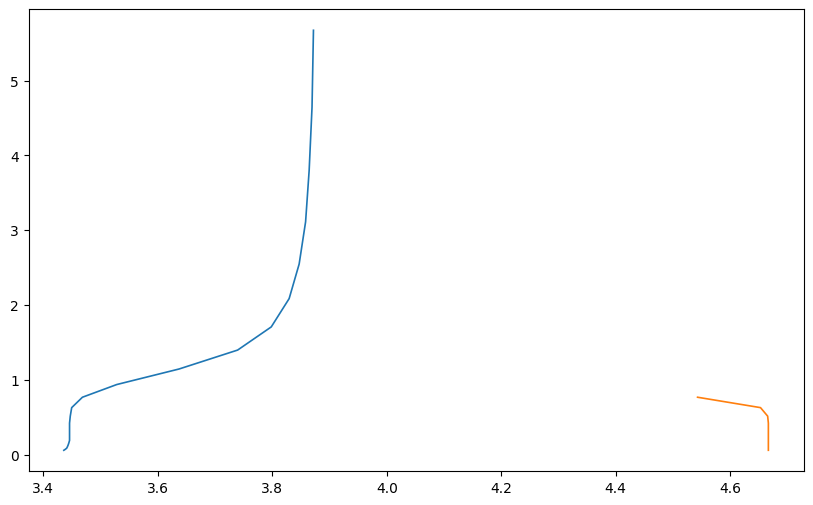

2025-08-08 10:24:00,359: systematic_plots: INFO: Intersection at 3.85 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,360: systematic_plots: INFO: Intersection at 3.85 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,362: systematic_plots: INFO: Intersection at 3.86 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,364: systematic_plots: INFO: Intersection at 3.86 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,365: systematic_plots: INFO: Intersection at 3.86 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,366: systematic_plots: INFO: Intersection at 5.17 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,367: systematic_plots: INFO: Intersection at 5.17 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,368: systematic_plots: INFO: Intersection at 5.19 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,369:

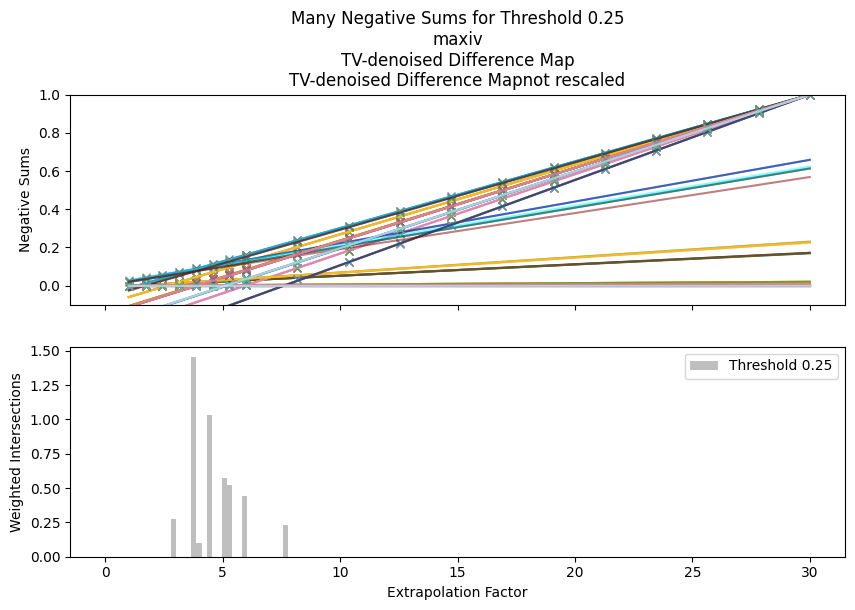

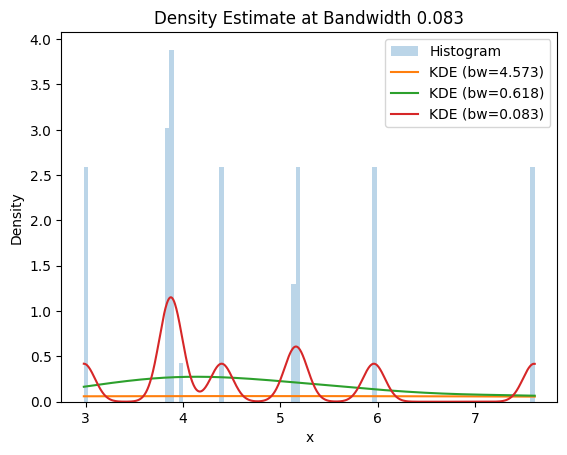

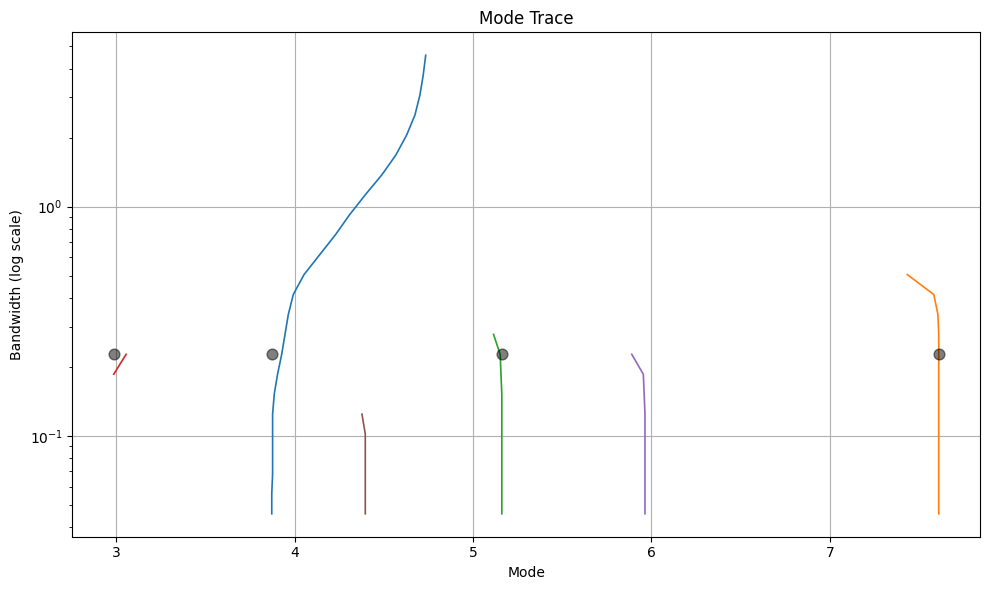

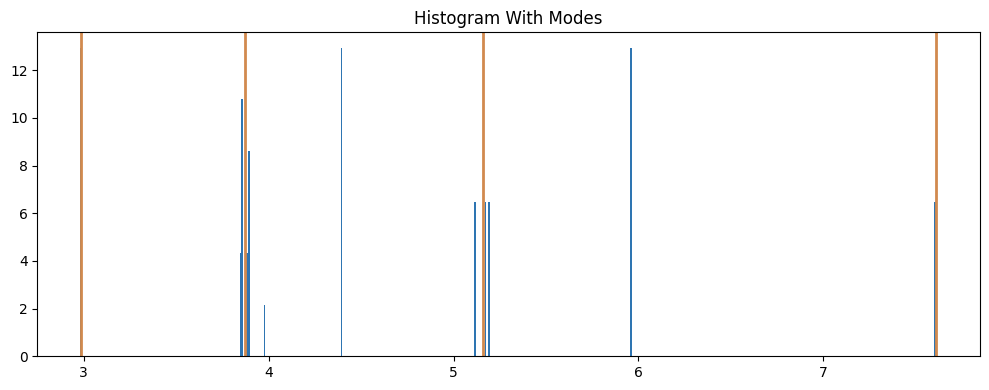

2025-08-08 10:24:00,998: systematic_plots: INFO: Intersection at 3.50 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:00,999: systematic_plots: INFO: Intersection at 3.50 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,001: systematic_plots: INFO: Intersection at 3.43 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,002: systematic_plots: INFO: Intersection at 4.66 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,003: systematic_plots: INFO: Intersection at 4.66 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,005: systematic_plots: INFO: Intersection at 4.66 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,006: systematic_plots: INFO: Intersection at 4.68 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,006: systematic_plots: INFO: Intersection at 3.43 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:01,007:

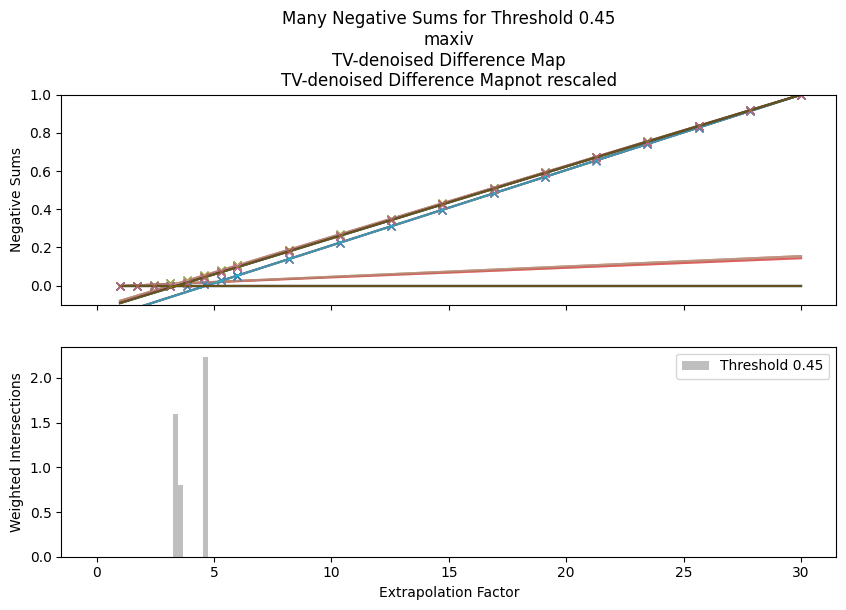

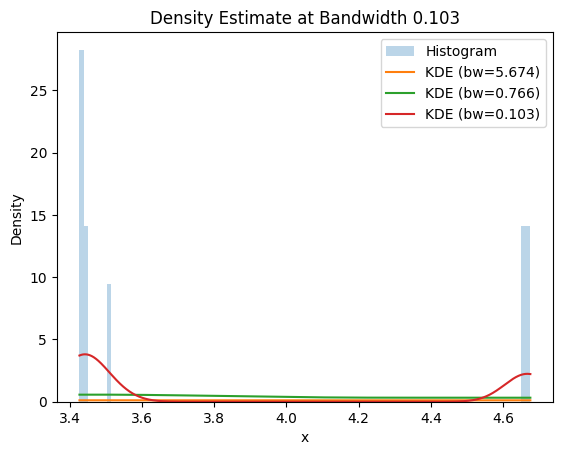

/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/systematic_plots.py:1704: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Plot 1: Mode Trace
2025-08-08 10:24:01,481: systematic_plots: WARNING: Error analyzing/plotting modes: 'Mode' (<string>:43)
2025-08-08 10:24:01,481: systematic_plots: INFO: Running Single NegSum (systematic_plots.py:1281)
2025-08-08 10:24:01,482: systematic_plots: WARNING: Calculating negsum for for single NSE 'manually' (<string>:3)
2025-08-08 10:24:01,482: systematic_plots: WARNING: This may cause slight differences to many nse version but is a lot faster' (<string>:4)
2025-08-08 10:24:08,465: systematic_plots: INFO: Intersection at 4.64 is between 3.14 and 21.27 (systematic_plots.py:400)
2025-08-08 10:24:08,467: systematic_plots: INFO: Intersection at 4.46 is b

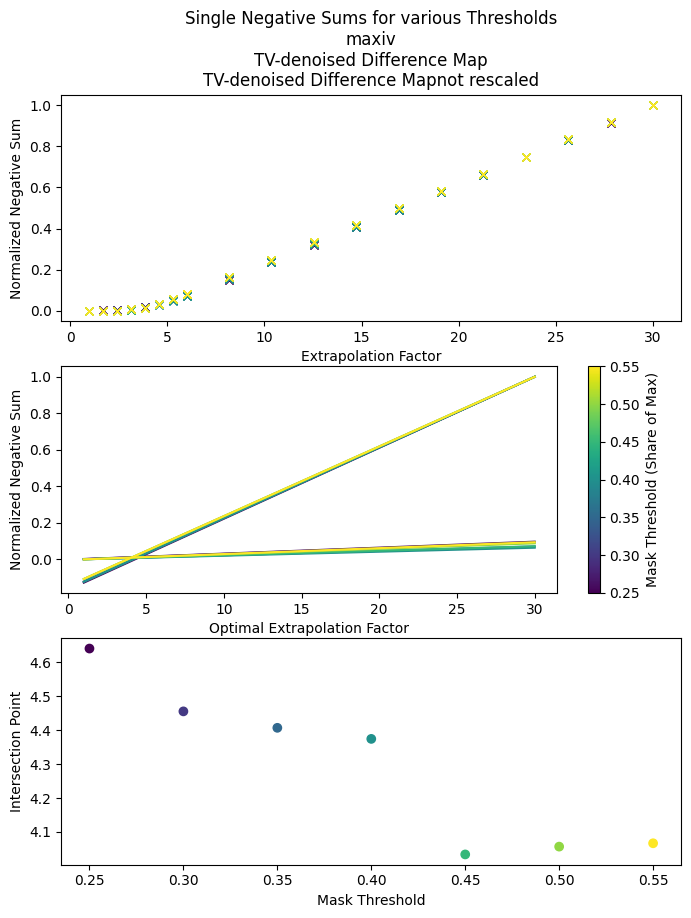

2025-08-08 10:24:08,595: root: INFO: Plotting many_negsum_best_guess with value_device={'thresholds': array([0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55]), 'best_guess': [4.626943831462022, 4.420581303433593, 4.488122093228828, 4.287525103247686, 4.0395181669569125, 3.967182967324678, 4.066329810647959], 'uncertainty': [1.0438586155579241, 1.0466000012985974, 1.0544621281854847, 0.6672807467615517, 0.6305289544267182, 0.6084406327715327, 0.6263492898960954]} (systematic_plots.py:803)
2025-08-08 10:24:08,597: root: INFO: Plotting single_negsum_overview with value_device={'thresholds': array([0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55]), 'best_guess': [4.640509595092287, 4.455350800179104, 4.406873872896192, 4.374238613279548, 4.033727248397377, 4.056749254785626, 4.066642919002999]} (systematic_plots.py:803)


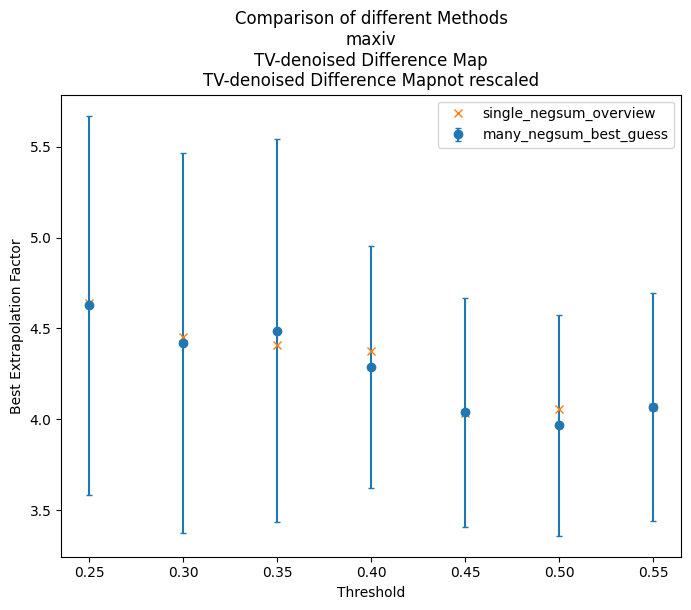

In [24]:
rho_shape = diffmap.to_3d_numpy_map(map_sampling=map_sampling).shape
info_container = {
    "tname": "maxiv",
    "fname": "maxiv",
    # "pdbloc_light": pdbloc_light,
    # "hs_limit": hs_limit,
    # "masks": {
    #     "ball": ccp4_to_mask(mask_loc_sphere, rho_shape),
    #     "handpicked": ccp4_to_mask(mask_loc_handcraft, rho_shape),
    # },
    "max_xtr_factor": 30,
    "mid_xtr_factor": 6,
    "map_sampling": map_sampling,
    "diffmap_config": diffmap_config,
    "fshort": "M4",
    "datatype": "M4",
    "minimum_threshold": 0.25,
    "maximum_threshold": 0.6
}
# diffmap_path = evaluation_path_basis + f"{key}/"
filestart = f"{info_container['fshort']}_{key}_"

filename_dict = {
            "save_fig": False,
            "display": True,
            "filestart": filestart,
            "rerun": True
            }
%matplotlib inline
function_selection = [
        "many_negsum_best_guess",
        "many_negsum_many_thresh",
        "single_negsum_overview",
        "show_comparison",
    ]


run_plots(diffmap, map_dark, info_container, key, filename_dict,function_selection=function_selection,)

In [ ]:
key = "tv"
comparison_key = "vanilla_diffmap"
scale_diffmap = False 

diffmaps, diffmap_config = loading_diffmaps(
    map_dark=map_dark,
    map_light=map_light,
    saveloc = saveloc,
    # map_sampling=map_sampling,
)

if scale_diffmap:
    diffmap = scale_maps(reference_map=diffmaps[comparison_key], map_to_scale=diffmaps[key])
else:
    diffmap = diffmaps[key]

# pos_blobs2, neg_blobs2 = find_largest_blobs2(diffmap=diffmap, map_sampling=map_sampling,
#                                               threshold=0.5, minimum_size=3)


Reading from diffmaps_tmp.mtz


2025-08-07 16:44:46,657: systematic_plots: INFO: Function selection provided: ['many_negsum_many_thresh'] (systematic_plots.py:1494)
2025-08-07 16:44:46,657: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1262)
2025-08-07 16:44:46,925: systematic_plots: INFO: Calculating many negsum for threshold 0.30 (systematic_plots.py:259)
2025-08-07 16:44:50,744: root: INFO: Unique intersection points: [4.13891691 4.13914599 4.13915416 4.14165698 4.14178521 4.14188651
                               4.2532028  4.25332401 4.2534226  4.25622045 4.25633365 4.2563444
                               4.42174084 4.42180491 4.42180618 4.4260577  4.42606569 4.48213265
                               4.48298622 4.48299843 4.48826428 4.48890321 4.489127   5.14907394
                               5.14912239 5.14912802 5.15178378 5.15183893 5.15190494 5.3042254
                               5.30422699 5.30422894 5.32480984 5.3248411  5.3248867  5.38110252
                         

intersection_points (47,)
-0.802967325475433
Bandwidth 0.5: Minima at [242], Maxima at [168 278]


IndexError: index 1 is out of bounds for axis 0 with size 1

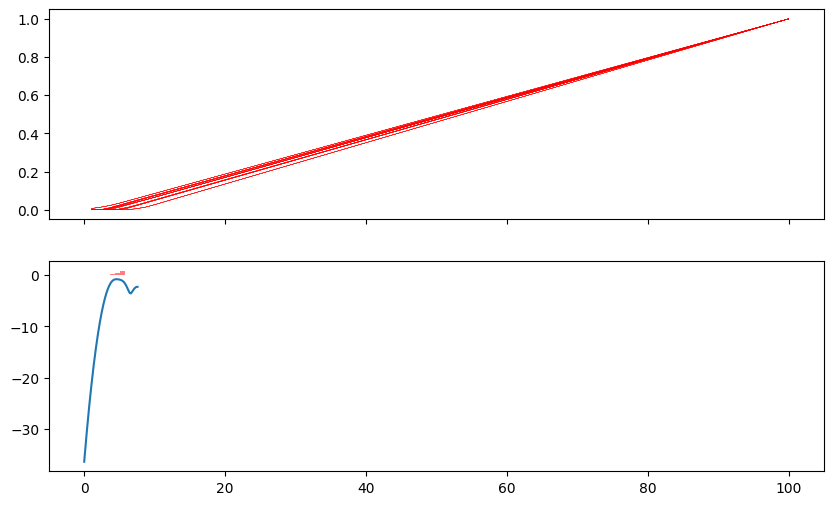

In [ ]:

from systematic_plots import run_plots
rho_shape = diffmap.to_3d_numpy_map(map_sampling=map_sampling).shape
info_container = {
    "tname": "maxiv",
    "fname": "maxiv",
    # "pdbloc_light": pdbloc_light,
    # "hs_limit": hs_limit,
    # "masks": {
    #     "ball": ccp4_to_mask(mask_loc_sphere, rho_shape),
    #     "handpicked": ccp4_to_mask(mask_loc_handcraft, rho_shape),
    # },
    "map_sampling": map_sampling,
    "diffmap_config": diffmap_config,
    "fshort": "M4",
    "datatype": "M4",
    "minimum_threshold": 0.3,
    "maximum_threshold": 0.5
}
# diffmap_path = evaluation_path_basis + f"{key}/"
filestart = f"{info_container['fshort']}_{key}_"

filename_dict = {
            "save_fig": False,
            "display": True,
            "filestart": filestart,
            "rerun": True
            }
%matplotlib inline
function_selection = [
        # "many_negsum_best_guess",
        "many_negsum_many_thresh",
        # "single_negsum_overview",
        # "show_comparison",
    ]


run_plots(diffmap, map_dark, info_container, key, filename_dict,function_selection=function_selection,)

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_8174/980006373.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for mode_id, group in df_modes.groupby('id'):


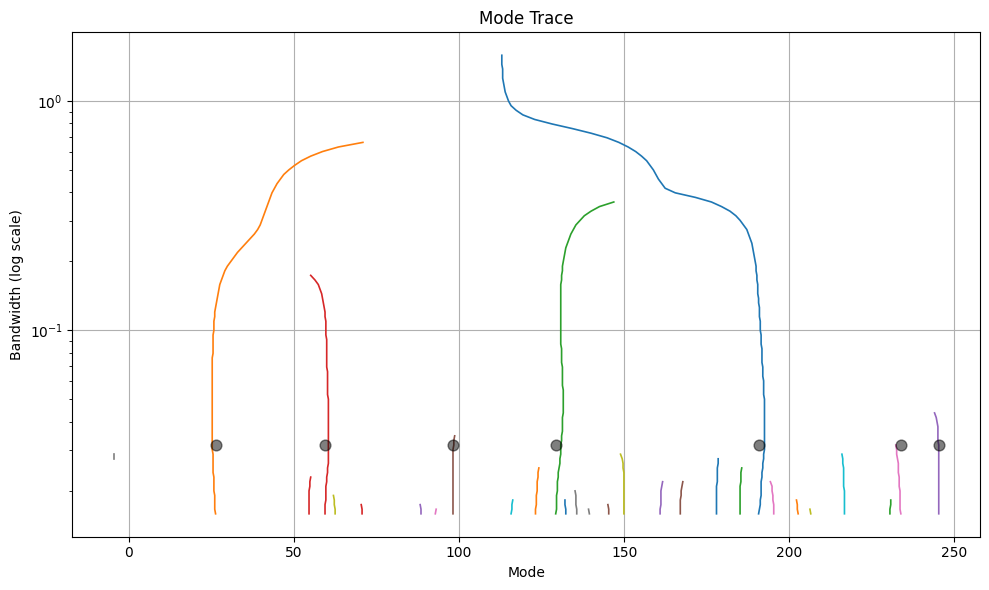

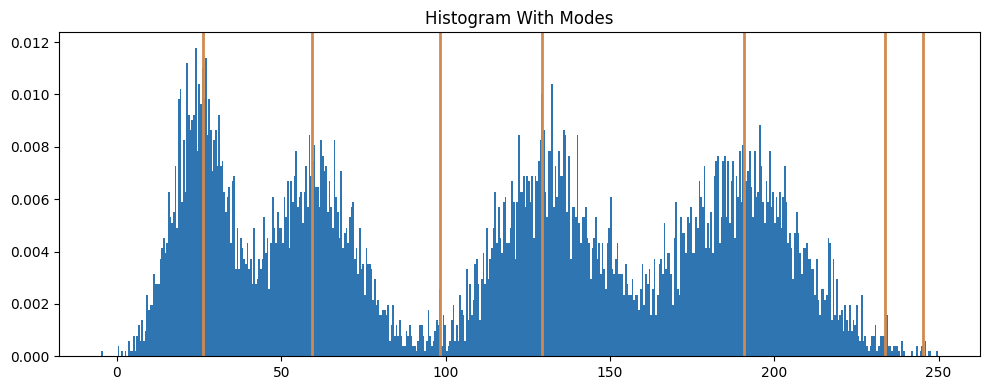

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from scipy.optimize import minimize_scalar
from scipy.stats import gaussian_kde
import pandas as pd

# ----------------------------
# Equivalent of rmix()
# ----------------------------
def rmix(n, mu, sigma, p):
    k = len(mu)
    components = np.random.choice(k, size=n, p=np.array(p)/np.sum(p))
    samples = np.array([np.random.normal(mu[i], sigma[i]) for i in components])
    return samples

# ----------------------------
# Parameters
# ----------------------------
mu = [25, 60, 130, 190]
sigma = [8, 13, 15, 19]
p = [0.18, 0.2, 0.24, 0.28]
n = int(1e4)
x = rmix(n, mu, sigma, p)

# ----------------------------
# Find local modes of KDE
# ----------------------------
def find_modes(kde_x, kde_y):
    y_prev = np.r_[kde_y[1:], np.nan]
    y_next = np.r_[np.nan, kde_y[:-1]]
    peaks = (kde_y > y_prev) & (kde_y > y_next)
    return kde_x[peaks]

# ----------------------------
# Mode trace over bandwidths
# ----------------------------
kde_default = gaussian_kde(x)
bw_default = kde_default.factor
bw_values = bw_default * 10**np.linspace(1, -1, 101)

mode_records = []
m = np.mean(x)
id_list = np.array([1])
id_counter = 1

for h in bw_values:
    kde = gaussian_kde(x, bw_method=h)
    kde_x = np.linspace(np.min(x), np.max(x), 1000)
    kde_y = kde(kde_x)
    m_new = np.sort(find_modes(kde_x, kde_y))
    
    if len(m_new) == 0:
        continue

    if len(m_new) == 1:
        delta = np.inf
    else:
        delta = np.min(np.diff(m_new)) / 2
    
    d = np.abs(m_new[:, None] - m)
    i = np.argmin(d, axis=0) if m.size else []
    for j in range(len(i)):
        if d[i[j], j] < delta:
            g[i[j]] = id_list[j]

    # Assign new IDs to unmatched modes
    unmatched = np.isnan(g)
    n_new = np.sum(unmatched)
    g[unmatched] = np.arange(id_counter + 1, id_counter + 1 + n_new)
    id_counter += n_new

    id_list = g.astype(int)
    m = m_new

    for mode_val, mode_id in zip(m_new, id_list):
        mode_records.append({'bw': h, 'Mode': mode_val, 'id': mode_id})

# ----------------------------
# Collect all mode traces
# ----------------------------
df_modes = pd.DataFrame(mode_records)
df_modes['id'] = df_modes['id'].astype('category')

# ----------------------------
# Find "most vertical" point per mode trace (minimum slope)
# ----------------------------
def minslope(x_vals, y_vals):
    def f(z): return np.interp(z, x_vals, y_vals)
    e = (np.max(x_vals) - np.min(x_vals)) * 1e-4
    def df2(z): return ((f(z + e) - f(z - e)) / (2 * e)) ** 2
    result = minimize_scalar(df2, bounds=(np.min(x_vals), np.max(x_vals)), method='bounded')
    return {'bw': result.x, 'slope': result.fun, 'Mode': f(result.x)}

# ----------------------------
# Select and refine desired modes
# ----------------------------
n_modes = 7  # User-selected
bw_max = df_modes[df_modes['id'] == n_modes]['bw'].max()

final_modes = []
for i in range(1, n_modes + 1):
    Y = df_modes[(df_modes['id'] == i) & (df_modes['bw'] <= bw_max)]
    if len(Y) >= 2:
        res = minslope(Y['bw'].values, Y['Mode'].values)
        final_modes.append(res)

df_final_modes = pd.DataFrame(final_modes)

# ----------------------------
# Plot 1: Mode Trace
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

for mode_id, group in df_modes.groupby('id'):
    ax.plot( group['Mode'],group['bw'], label=f'Mode {mode_id}', linewidth=1.2)

ax.scatter( df_final_modes['Mode'],df_final_modes['bw'],
           color='black', s=60, alpha=0.5, zorder=5)

ax.set_yscale('log')
# ax.invert_yaxis()
ax.set_ylabel('Bandwidth (log scale)')
ax.set_xlabel('Mode')
ax.set_title('Mode Trace')
ax.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Histogram With Modes
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(x, bins=500, density=True, color='#2E75B2', edgecolor='none')

for mode in df_final_modes['Mode']:
    ax.axvline(mode, color='#D18A4e', linewidth=2)

ax.set_title('Histogram With Modes')
plt.tight_layout()
plt.show()


In [ ]:
def create_histogram_data(n=10000, mu=None, sigma=None, p=None, bins=1000):
    if mu is None:
        mu = [25, 60, 130, 190]
    if sigma is None:
        sigma = [8, 13, 15, 19]
    if p is None:
        p = [0.18, 0.2, 0.24, 0.28]
    def rmix(n, mu, sigma, p):
        k = len(mu)
        components = np.random.choice(k, size=n, p=np.array(p)/np.sum(p))
        samples = np.array([np.random.normal(mu[i], sigma[i]) for i in components])
        return samples
    x = rmix(n, mu, sigma, p)
    hist, bin_edges = np.histogram(x, bins=bins, density=True)
    return x, hist, bin_edges

def analyze_modes(x, n_modes=7):

    def find_modes(kde_x, kde_y):
        y_prev = np.roll(kde_y, -1)
        y_next = np.roll(kde_y, 1)
        peaks = (kde_y > y_prev) & (kde_y > y_next)
        # Exclude endpoints which are artifacts of np.roll
        peaks[0] = peaks[-1] = False
        return kde_x[peaks]

    kde_default = gaussian_kde(x)
    bw_default = kde_default.factor
    bw_values = bw_default * 10**np.linspace(1, -1, 101)

    mode_records = []
    m = np.mean(x)
    id_list = np.array([1])
    id_counter = 1

    for h in bw_values:
        kde = gaussian_kde(x, bw_method=h)
        kde_x = np.linspace(np.min(x), np.max(x), 1000)
        kde_y = kde(kde_x)
        m_new = np.sort(find_modes(kde_x, kde_y))
        if len(m_new) == 0:
            continue
        delta = np.inf if len(m_new) == 1 else np.min(np.diff(m_new)) / 2
        d = np.abs(m_new[:, None] - m)
        g = np.full(len(m_new), np.nan)
        if m.size:
            i = np.argmin(d, axis=0)
            g[i] = np.where(d[i, np.arange(len(i))] < delta, id_list, np.nan)
        unmatched = np.isnan(g)
        n_new = np.sum(unmatched)
        g[unmatched] = np.arange(id_counter + 1, id_counter + 1 + n_new)
        id_counter += n_new
        id_list = g.astype(int)
        m = m_new
        mode_records.extend({'bw': h, 'Mode': mode_val, 'id': mode_id} for mode_val, mode_id in zip(m_new, id_list))
    df_modes = pd.DataFrame(mode_records)
    df_modes['id'] = df_modes['id'].astype('category')
    # Plot x and density for every tenth bandwidth
    for idx, h in enumerate(bw_values[::10]):
        kde = gaussian_kde(x, bw_method=h)
        kde_x = np.linspace(np.min(x), np.max(x), 1000)
        kde_y = kde(kde_x)
        plt.figure()
        plt.hist(x, bins=100, density=True, alpha=0.3, label='Histogram')
        plt.plot(kde_x, kde_y, label=f'KDE (bw={h:.3f})')
        plt.title(f'Density Estimate at Bandwidth {h:.3f}')
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

    def minslope(x_vals, y_vals):
        def f(z): return np.interp(z, x_vals, y_vals)
        e = (np.max(x_vals) - np.min(x_vals)) * 1e-4
        def df2(z): return ((f(z + e) - f(z - e)) / (2 * e)) ** 2
        result = minimize_scalar(df2, bounds=(np.min(x_vals), np.max(x_vals)), method='bounded')
        return {'bw': result.x, 'slope': result.fun, 'Mode': f(result.x)}

    bw_max = df_modes[df_modes['id'] == n_modes]['bw'].max()
    final_modes = []
    for i in range(1, n_modes + 1):
        Y = df_modes[(df_modes['id'] == i) & (df_modes['bw'] <= bw_max)]
        if len(Y) >= 2:
            res = minslope(Y['bw'].values, Y['Mode'].values)
            final_modes.append(res)
    df_final_modes = pd.DataFrame(final_modes)
    return df_modes, df_final_modes

# Usage example:
def plot_modes(df_modes, df_final_modes):
    # Plot 1: Mode Trace
    fig, ax = plt.subplots(figsize=(10, 6))
    for mode_id, group in df_modes.groupby('id'):
        ax.plot(group['Mode'], group['bw'], label=f'Mode {mode_id}', linewidth=1.2)
    ax.scatter(df_final_modes['Mode'], df_final_modes['bw'], color='black', s=60, alpha=0.5, zorder=5)
    ax.set_yscale('log')
    ax.set_ylabel('Bandwidth (log scale)')
    ax.set_xlabel('Mode')
    ax.set_title('Mode Trace')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot 2: Histogram With Modes
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(x, bins=500, density=True, color='#2E75B2', edgecolor='none')
    for mode in df_final_modes['Mode']:
        ax.axvline(mode, color='#D18A4e', linewidth=2)
    ax.set_title('Histogram With Modes')
    plt.tight_layout()
    plt.show()

    # x, _ ,_  = create_histogram_data()
    # analyze_modes(x, n_modes=4)

(4, 100)


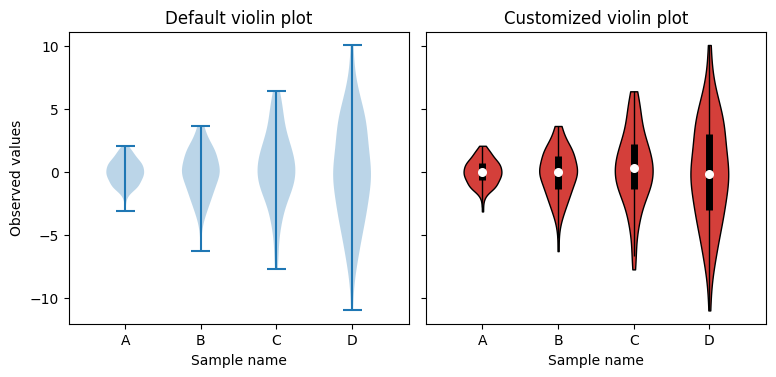

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value


def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Sample name')


# create test data
np.random.seed(19680801)
data = [sorted(np.random.normal(0, std, 100)) for std in range(1, 5)]
print(np.shape(data))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharey=True)

ax1.set_title('Default violin plot')
ax1.set_ylabel('Observed values')
ax1.violinplot(data)

ax2.set_title('Customized violin plot')
parts = ax2.violinplot(
        data, showmeans=False, showmedians=False,
        showextrema=False)

for pc in parts['bodies']:
    pc.set_facecolor('#D43F3A')
    pc.set_edgecolor('black')
    pc.set_alpha(1)

quartile1, medians, quartile3 = np.percentile(data, [25, 50, 75], axis=1)
whiskers = np.array([
    adjacent_values(sorted_array, q1, q3)
    for sorted_array, q1, q3 in zip(data, quartile1, quartile3)])
whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]

inds = np.arange(1, len(medians) + 1)
ax2.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
ax2.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
ax2.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)

# set style for the axes
labels = ['A', 'B', 'C', 'D']
for ax in [ax1, ax2]:
    set_axis_style(ax, labels)

plt.subplots_adjust(bottom=0.15, wspace=0.05)
plt.show()

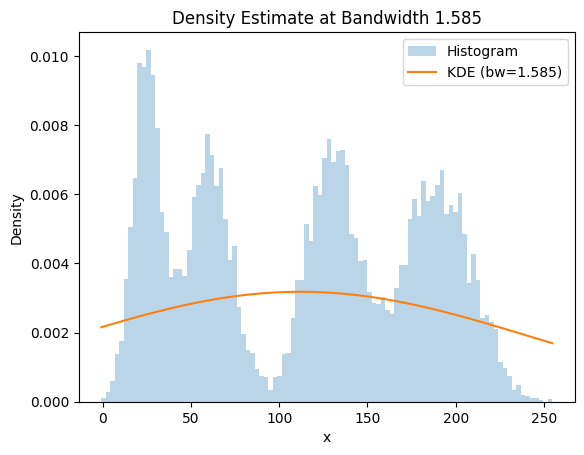

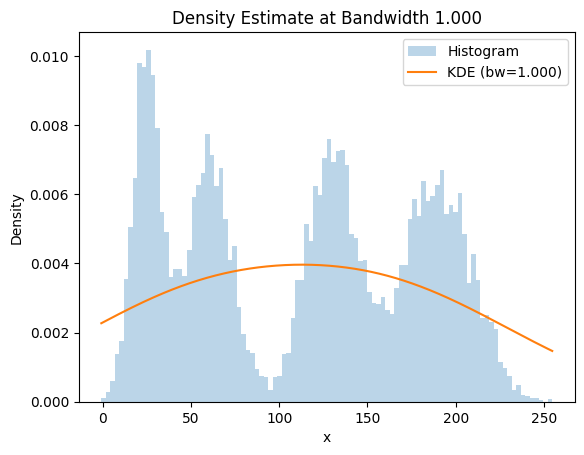

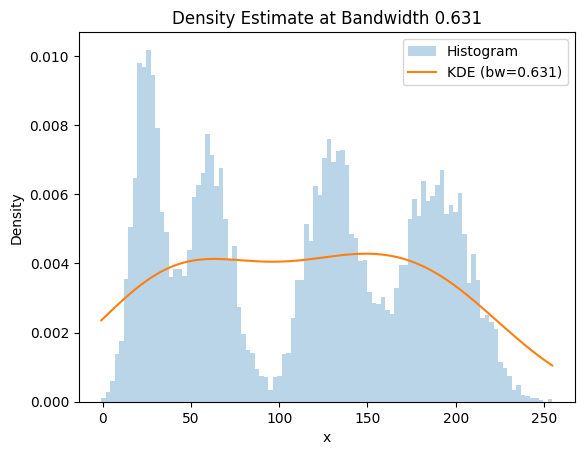

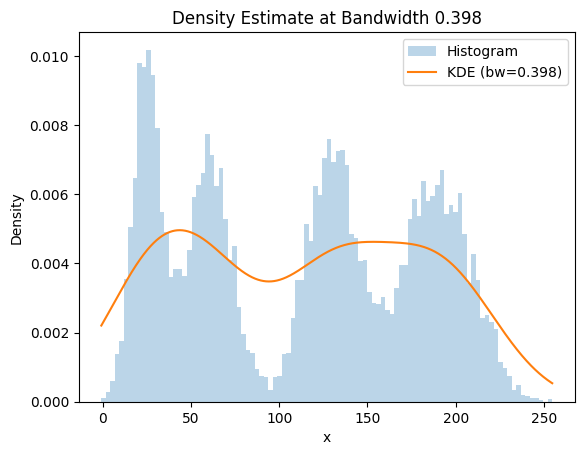

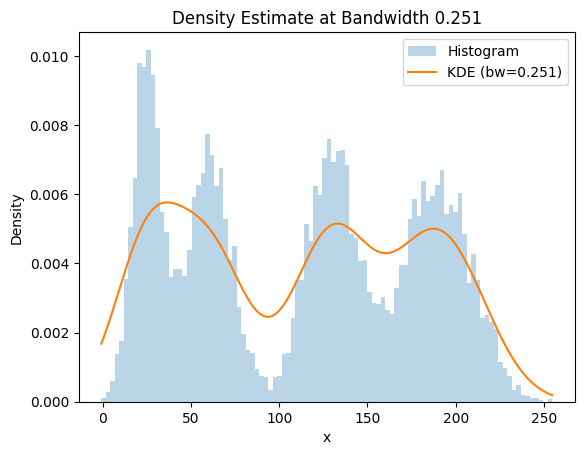

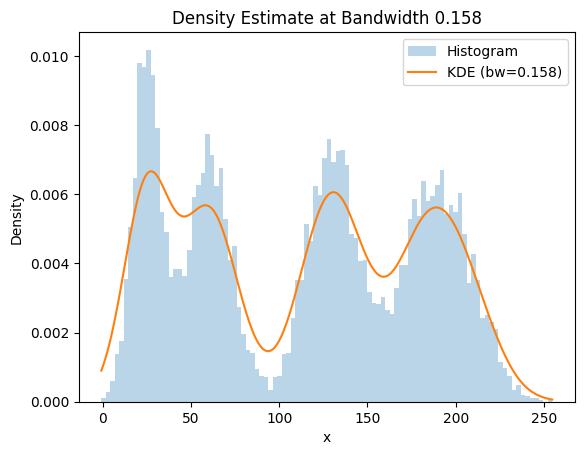

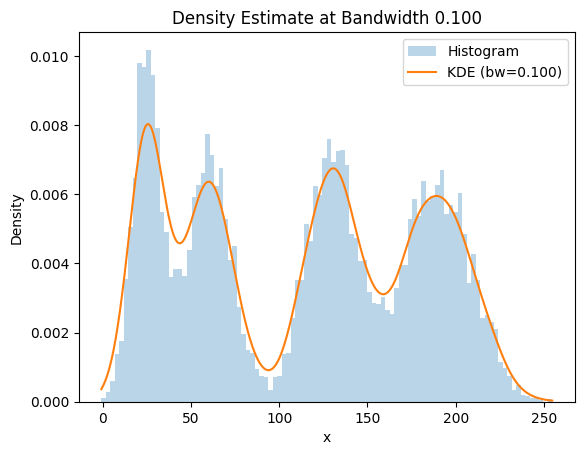

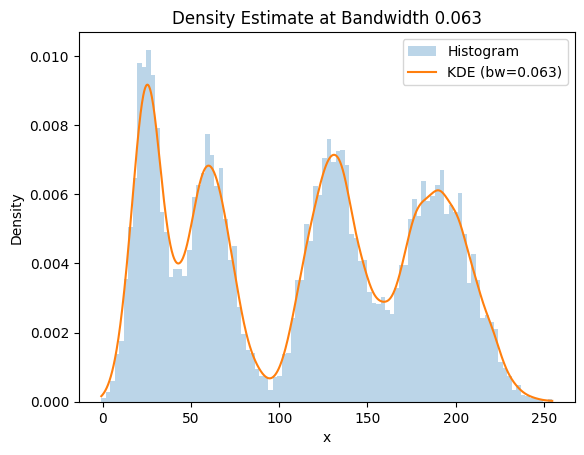

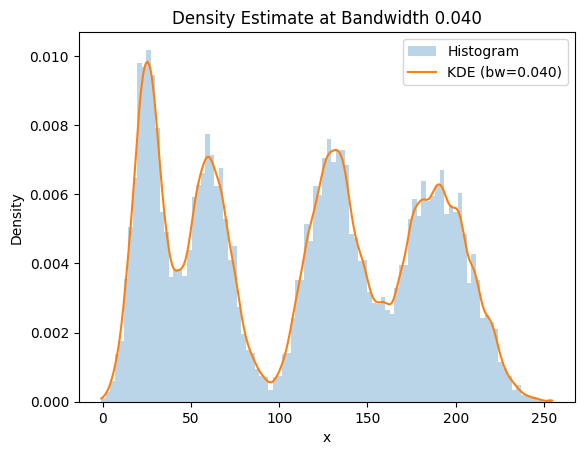

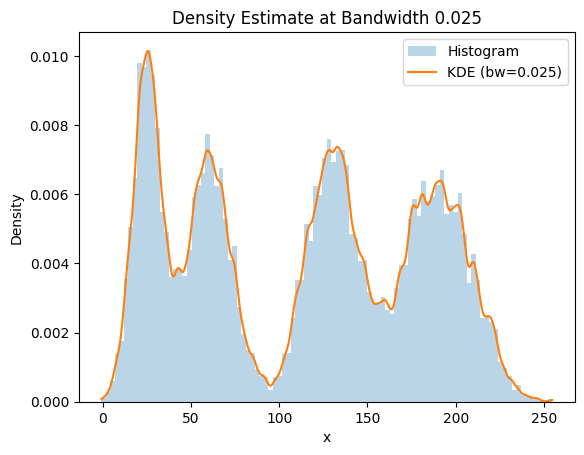

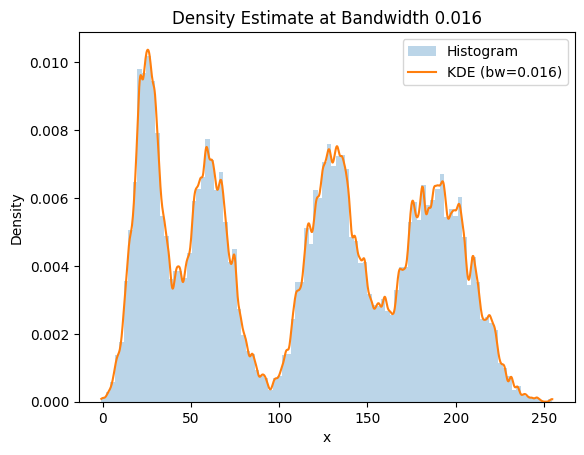

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_8174/2205832411.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for mode_id, group in df_modes.groupby('id'):


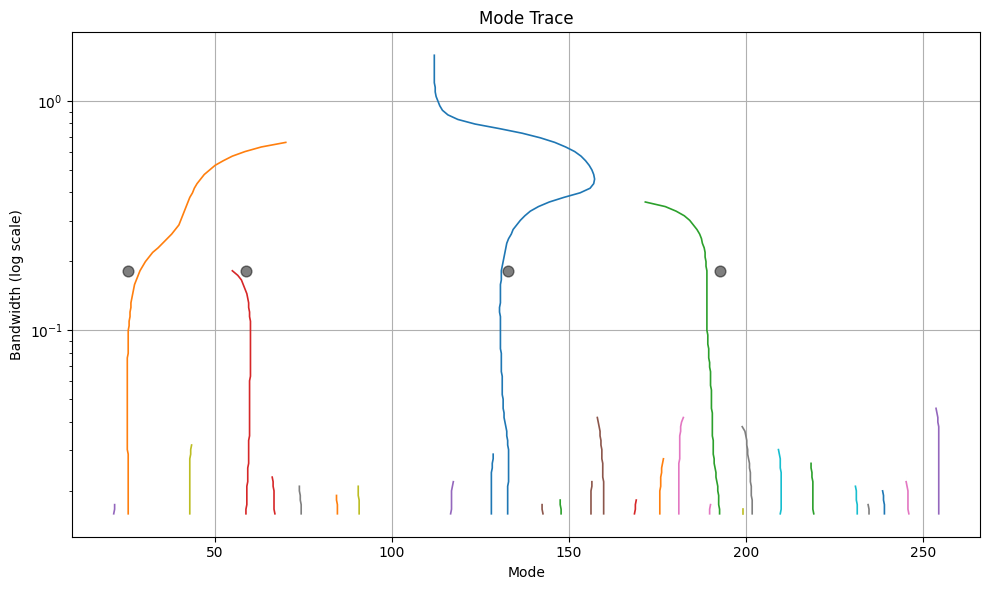

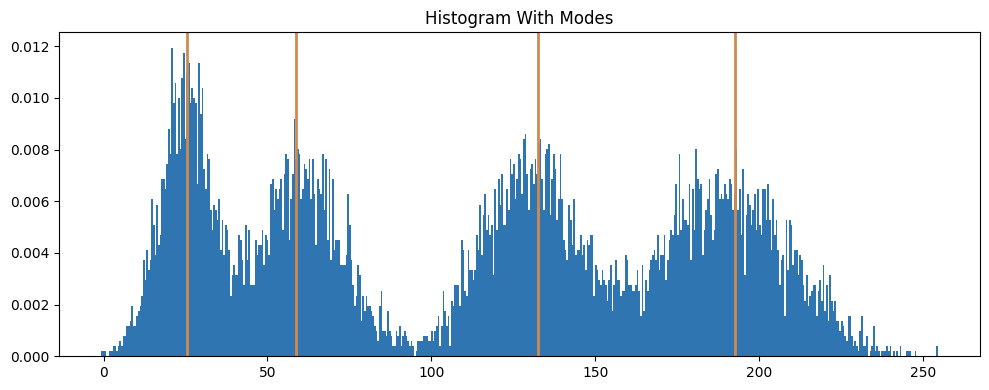

In [ ]:

x, hist, bin_edges = create_histogram_data()
df_modes, df_final_modes = analyze_modes(x, 4)
plot_modes(df_modes, df_final_modes)